# 05. Quarterly Model Setup for Thailand

The monthly specification was not suitable for final modeling, so quarterly data are adopted as the main frequency.
Based on quarterly stationarity diagnostics, the baseline reduced-form model is estimated on first-differenced quarterly data.
For modeling purposes, GDP and CPI are treated as I(1)-type variables with caution (while acknowledging possible borderline behavior in finite samples).

Scope: build the baseline VAR setup and diagnostics only. Structural interpretation and detailed IRF/FEVD discussion are deferred to the next notebook.

In [17]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

plt.rcParams['figure.dpi'] = 140
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)

## 1. Load and Inspect Quarterly Data

In [18]:
data_path = '../../data/processed/THA_model_ready_quarterly.csv'
df = pd.read_csv(data_path, parse_dates=['date'], index_col='date')

# Ensure datetime index and sorted order
df.index = pd.to_datetime(df.index)
df = df.sort_index()

print('Shape:', df.shape)
print('Date range:', df.index.min(), 'to', df.index.max())
print('Missing values by variable:')
print(df.isnull().sum())
print('Head:')
print(df.head())

Shape: (73, 5)
Date range: 2006-03-31 00:00:00 to 2024-03-31 00:00:00
Missing values by variable:
ln_WTI      0
ln_GDP      0
ln_CPI      0
Interest    0
ln_FX       0
dtype: int64
Head:
             ln_WTI    ln_GDP   ln_CPI  Interest    ln_FX
date                                                     
2006-03-31 4.147038 26.155337 4.508159  6.254871 3.627030
2006-06-30 4.254329 26.199388 4.513737  6.198061 3.604410
2006-09-30 4.252125 26.241580 4.519283  6.141251 3.581267
2006-12-31 4.093711 26.282063 4.524800  6.084442 3.557576
2007-03-31 4.060750 26.313068 4.533001  6.027845 3.538570


## 2. Create Quarterly Modeling Dataset
Baseline dataset is first-differenced quarterly data for VAR estimation.

In [11]:
df_model = df.diff().dropna()
print('Model dataset shape (diff1):', df_model.shape)
print('Model date range:', df_model.index.min(), 'to', df_model.index.max())
print('Head of model dataset:')
print(df_model.head())

Model dataset shape (diff1): (72, 5)
Model date range: 2006-06-30 00:00:00 to 2024-03-31 00:00:00
Head of model dataset:
              ln_WTI   ln_GDP   ln_CPI  Interest     ln_FX
date                                                      
2006-06-30  0.107291 0.044051 0.005578 -0.056810 -0.022619
2006-09-30 -0.002204 0.042192 0.005547 -0.056810 -0.023143
2006-12-31 -0.158414 0.040484 0.005516 -0.056810 -0.023691
2007-03-31 -0.032961 0.031005 0.008202 -0.056597 -0.019006
2007-06-30  0.112854 0.026215 0.013518 -0.056170 -0.008790


## 3. Quick Visual Check of Modeling Series

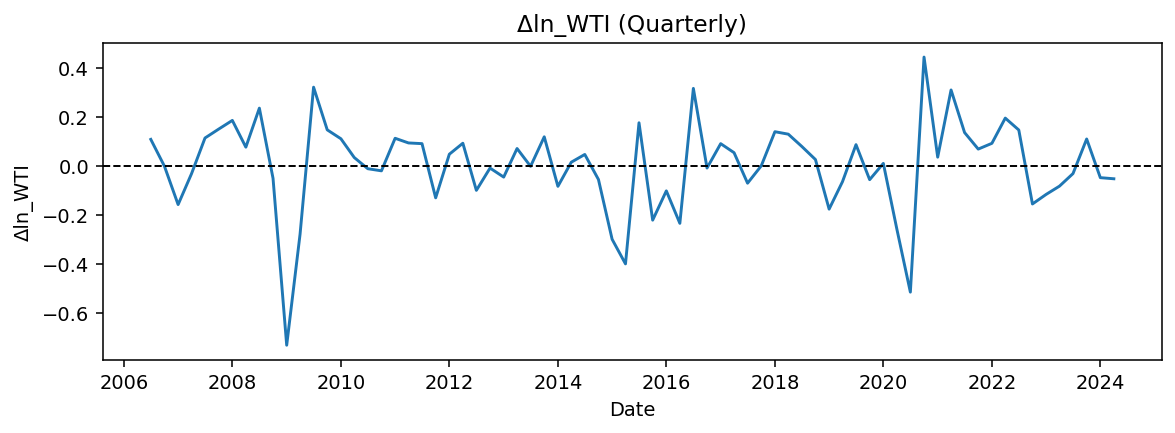

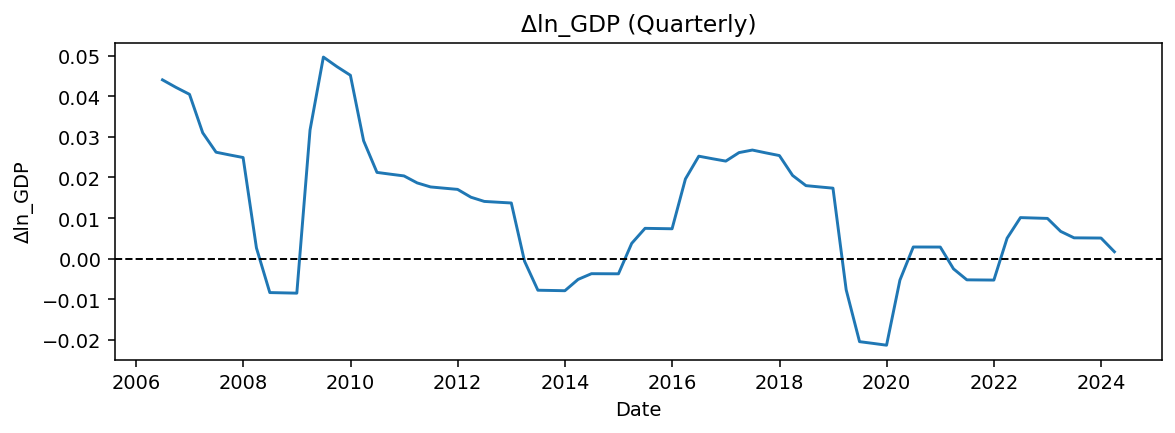

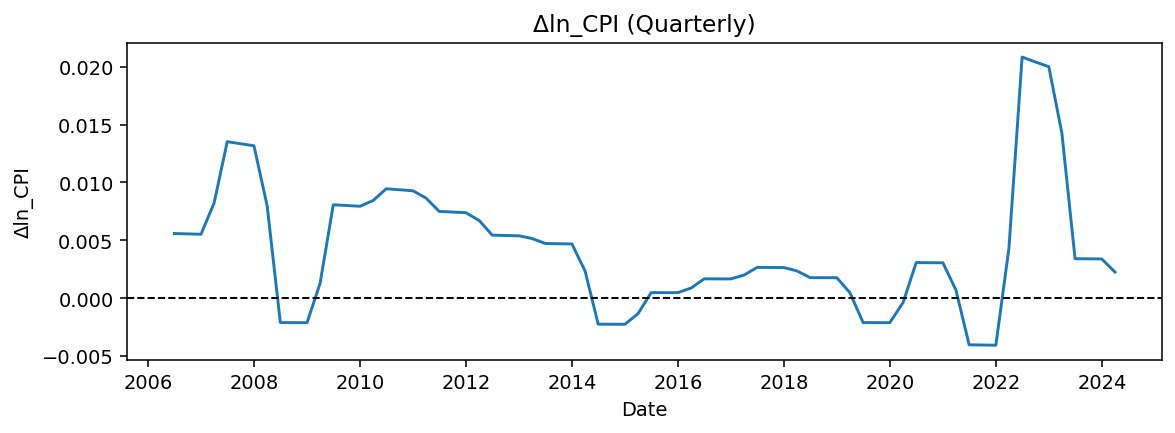

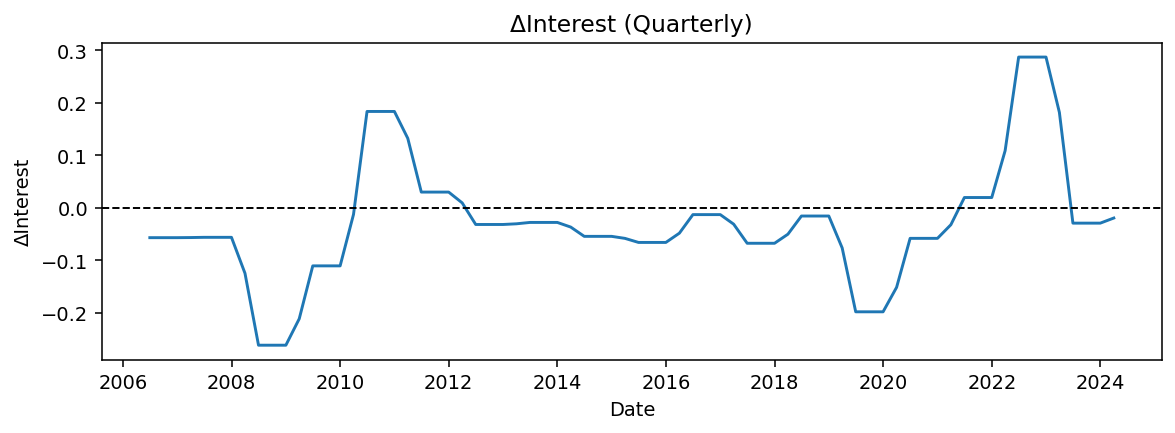

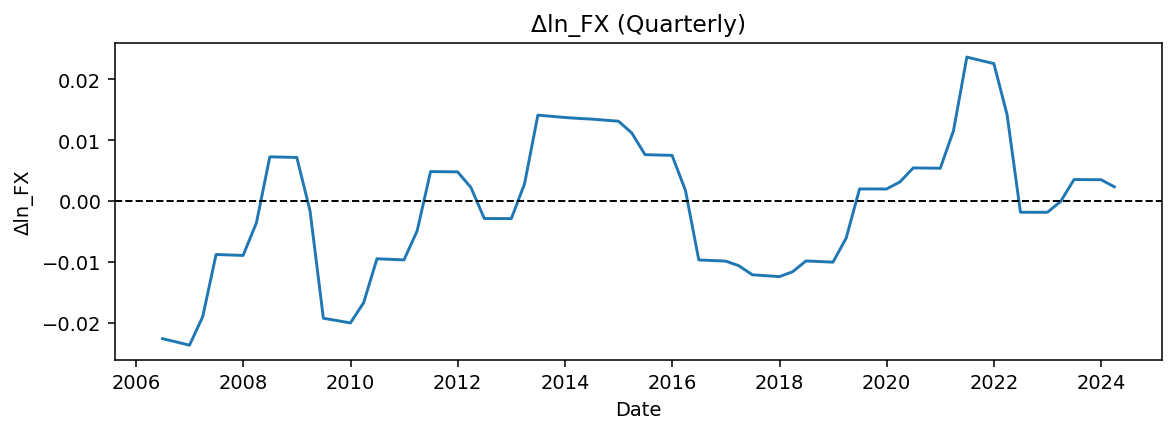

In [12]:
for col in df_model.columns:
    plt.figure(figsize=(8.5, 3.2))
    plt.plot(df_model.index, df_model[col], color='tab:blue')
    plt.axhline(0.0, color='black', linestyle='--', linewidth=1)
    plt.title(f'Δ{col} (Quarterly)')
    plt.xlabel('Date')
    plt.ylabel(f'Δ{col}')
    plt.tight_layout()
    plt.show()

## 4. VAR Lag-Length Selection
Keep the standard lag-order selection table, then evaluate candidate lags with post-estimation diagnostics (stability and whiteness).
Final lag is selected using both parsimony and model adequacy.

In [13]:
model = VAR(df_model)
lag_selection = model.select_order(maxlags=4)

print(lag_selection.summary())
print('Selected orders by criterion:', lag_selection.selected_orders)

candidate_lags = [1, 2, 3, 4]
diag_rows = []

for p in candidate_lags:
    row = {'lag': p}
    try:
        res_p = model.fit(p)
        row['aic'] = res_p.aic
        row['bic'] = res_p.bic
        row['hqic'] = res_p.hqic
        row['fpe'] = res_p.fpe
        row['stable'] = bool(res_p.is_stable(verbose=False))

        white_test = res_p.test_whiteness(nlags=max(8, p + 2))
        row['white_pvalue'] = float(white_test.pvalue)
        row['white_ok_5pct'] = bool(white_test.pvalue >= 0.05)
        row['estimable'] = True
    except Exception as e:
        row['aic'] = None
        row['bic'] = None
        row['hqic'] = None
        row['fpe'] = None
        row['stable'] = False
        row['white_pvalue'] = None
        row['white_ok_5pct'] = False
        row['estimable'] = False
        row['error'] = str(e)

    diag_rows.append(row)

lag_diag = pd.DataFrame(diag_rows)
lag_diag['adequate'] = lag_diag['estimable'] & lag_diag['stable'] & lag_diag['white_ok_5pct']

print('Candidate lag diagnostics:')
print(lag_diag[['lag', 'aic', 'bic', 'hqic', 'stable', 'white_pvalue', 'white_ok_5pct', 'adequate']].to_string(index=False))

adequate_pool = lag_diag[lag_diag['adequate']].copy()
if not adequate_pool.empty:
    selected_lag = int(adequate_pool.sort_values(['bic', 'lag']).iloc[0]['lag'])
    selection_reason = 'Selected from adequate models (stable + whiteness p>=0.05) using lowest BIC.'
else:
    selected_lag = int(lag_diag.dropna(subset=['bic']).sort_values(['bic', 'lag']).iloc[0]['lag'])
    selection_reason = 'No lag passed adequacy; fallback to lowest BIC among estimable lags.'

print('Final selected lag:', selected_lag)
print('Selection reason:', selection_reason)

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -37.41      -37.24   5.681e-17      -37.34
1      -42.42     -41.45*   3.770e-19     -42.04*
2     -42.74*      -40.95  2.773e-19*      -42.03
3      -42.72      -40.10   2.939e-19      -41.68
4      -42.37      -38.94   4.401e-19      -41.01
-------------------------------------------------
Selected orders by criterion: {'aic': np.int64(2), 'bic': np.int64(1), 'hqic': np.int64(1), 'fpe': np.int64(2)}
Candidate lag diagnostics:
 lag        aic        bic       hqic  stable  white_pvalue  white_ok_5pct  adequate
   1 -42.563483 -41.607421 -42.183287    True      0.001834          False     False
   2 -42.817062 -41.050387 -42.115317    True      0.018078          False     False
   3 -42.737859 -40.147591 -41.710213    True      0.023232          False     False
   4 -42.371571 -38.944390 -41.013617    True      0.000335          Fa

/Users/thutrang/Desktop/Code/NEU/TimeSeries/asean3-oil-shock-svar/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)


## 5. Estimate Baseline VAR on First Differences

In [14]:
var_res = model.fit(selected_lag)
print(var_res.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 01, Apr, 2026
Time:                     11:30:59
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                   -41.6074
Nobs:                     71.0000    HQIC:                  -42.1833
Log likelihood:           1037.28    FPE:                3.27938e-19
AIC:                     -42.5635    Det(Omega_mle):     2.18590e-19
--------------------------------------------------------------------
Results for equation ln_WTI
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const              -0.064690         0.046174           -1.401           0.161
L1.ln_WTI           0.075653         0.118686            0.637           0.524
L1.ln_GDP           5.599567         2.321321            2.412     

## 6. Stability and Basic Diagnostics
Check whether the fitted VAR is dynamically stable and whether residual diagnostics are broadly acceptable.

In [15]:
# Stability
is_stable = var_res.is_stable(verbose=False)
root_modulus = pd.Series([abs(x) for x in var_res.roots], name='abs_root')

print('VAR stability (all roots outside unit circle):', is_stable)
print('Root moduli (sorted):')
print(root_modulus.sort_values().to_string(index=False))

# Residual serial-correlation test (Portmanteau / whiteness)
try:
    white = var_res.test_whiteness(nlags=selected_lag + 2)
    print('\nResidual whiteness test:')
    print(white)
except Exception as e:
    print('\nWhiteness test unavailable:', str(e))

# Residual normality test
try:
    normality = var_res.test_normality()
    print('\nResidual normality test:')
    print(normality)
except Exception as e:
    print('\nNormality test unavailable:', str(e))

VAR stability (all roots outside unit circle): True
Root moduli (sorted):
1.093628
1.218312
1.266021
1.266021
6.574855

Residual whiteness test:
<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 3 is zero: reject at 5% significance level. Test statistic: 80.108, critical value: 67.505>, p-value: 0.004>

Residual normality test:
<statsmodels.tsa.vector_ar.hypothesis_test_results.NormalityTestResults object. H_0: data generated by normally-distributed process: reject at 5% significance level. Test statistic: 702.626, critical value: 18.307>, p-value: 0.000>


## 7. Readiness for Next-Step Structural Analysis

The quarterly first-differenced VAR specification has now been established as a baseline reduced-form model for Thailand.

Among the candidate lag lengths, none fully satisfies the adequacy criterion based on the residual whiteness test. Although higher lags slightly improve the whiteness p-value, they do not eliminate residual autocorrelation and come at the cost of greater model complexity. Given the limited sample size and BIC’s preference for parsimony, lag 1 is retained as the baseline specification.

The fitted VAR is dynamically stable, which supports proceeding to the next stage of analysis. However, because residual diagnostics remain imperfect, especially with respect to serial correlation, subsequent IRF and SVAR results should be interpreted with caution.